# 06 Fine-tuned Transformer

**Owner:** Michael Nwuju

This notebook tests whether pretrained transformers help with Swahili news classification, and which kind of pretraining helps most.

| # | Experiment | Question it answers |
|---|---|---|
| 1 | Small transformer trained from scratch | Lower bound: how much does pretraining matter? |
| 2 | Fine-tuned AfriBERTa | Does small, Africa-only pretraining help? |
| 3 | Fine-tuned XLM-R | Is a large general multilingual model better? |
| 4 | Fine-tuned AfroXLMR | Does adapting XLM-R to African languages help? |
| 5 | First 128 + last 382 tokens | Is keeping the end of long articles better than keeping only the start? |
| 6 | Class weights | Does weighting help `kimataifa` and `burudani`? |
| 7 | Final model with 3 seeds and calibration | How stable is the result, and does temperature scaling improve log loss? |

**Before you run:** in Colab, go to *Runtime > Change runtime type* and choose a **T4 GPU**. Each fine-tuning experiment takes several minutes on a GPU and would take hours on a CPU.

**If Colab disconnects:** results are backed up to Google Drive after every experiment. Run section 1 and 2 again, then continue from the experiment you were on. Each experiment cell is self-contained.

## 1. Setup

In [1]:
MEMBER = "Michael Nwuju"
MODEL_NAME = "transformer"

In [2]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    %pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("Working directory:", os.getcwd())

Cloning into 'nlp_language_technologies'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 180 (delta 74), reused 157 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 7.58 MiB | 23.81 MiB/s, done.
Resolving deltas: 100% (74/74), done.
/content/nlp_language_technologies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.0 MB/s eta 0:00:00
Working directory: /content/nlp_language_technologies


In [3]:
import shutil

import pandas as pd
import torch

from src import config
from src import data_loading
from src import evaluation
from src import plots
from src import transformer_training
from src.calibration import find_best_temperature, softmax
from src.experiment_log import EXPERIMENT_LOGS_DIRECTORY, log_experiment
from src.reproducibility import FINAL_RUN_SEEDS

device = transformer_training.get_device()

print("Device:", device)

if device.type == "cpu":
    print("WARNING: no GPU found. Change the Colab runtime to a T4 GPU before training.")

Device: cuda


### Back up results to Google Drive

Colab deletes files when the session ends. These two functions copy `results/` to your Google Drive after every experiment, and copy it back when you reconnect.

In [4]:
BACKUP_DIRECTORY = Path("/content/drive/MyDrive/nlp_language_technologies_results")

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")


def back_up_results() -> None:
    if IN_COLAB:
        shutil.copytree("results", BACKUP_DIRECTORY, dirs_exist_ok=True)

        print("Backed up results to Google Drive")


def restore_results() -> None:
    if IN_COLAB and BACKUP_DIRECTORY.exists():
        shutil.copytree(BACKUP_DIRECTORY, "results", dirs_exist_ok=True)

        print("Restored results from Google Drive")


restore_results()

Mounted at /content/drive


## 2. Load the data

In [5]:
train = data_loading.load_train()

validation = data_loading.load_validation()

test = data_loading.load_test()

zindi_test = data_loading.load_zindi_test()

validation_ids = data_loading.labels_to_ids(validation["category"])

test_ids = data_loading.labels_to_ids(test["category"])

print("Sizes:", len(train), len(validation), len(test), len(zindi_test))

Sizes: 3603 772 773 1288


## 3. Shared settings

Every experiment starts from these settings and changes only what it is testing, so any difference in the results comes from that one change.

| Setting | Value | Why |
|---|---|---|
| `strategy` | `head` | Keep the first 510 tokens. News articles put the main topic at the start |
| `learning_rate` | 2e-5 | A standard fine-tuning rate for BERT-style models |
| `epochs` | 4 | Fine-tuning usually converges in a few epochs |
| `patience` | 2 | Stop early if validation loss does not improve for 2 epochs |
| `batch_size` | 8 | Fits a 512-token base model on a T4 GPU |
| `class_weights` | `False` | Tested separately in experiment 6 |

The model with the lowest validation loss across the epochs is kept.

In [6]:
BASE_SETTINGS = {
    "epochs": 4,
    "patience": 2,
    "batch_size": 8,
    "strategy": "head",
    "from_scratch": False,
    "learning_rate": 2e-5,
    "class_weights": False,
    "seed": config.RANDOM_SEED,
    "checkpoint": "castorini/afriberta_large",
}

In [7]:
def evaluate_experiment(experiment_name, settings, model, tokenizer, history, notes):
    validation_logits = transformer_training.predict_article_logits(model, tokenizer, validation, settings)

    validation_probabilities = softmax(validation_logits)

    validation_scores = evaluation.compute_scores(validation_ids, validation_probabilities)

    evaluation.print_classification_report(validation_ids, validation_probabilities)

    log_experiment(MEMBER, MODEL_NAME, experiment_name, "validation", settings, validation_scores, notes)

    plots.plot_learning_curves(history, MODEL_NAME, experiment_name)

    back_up_results()

    return validation_scores

## 4. Experiment 1: small transformer trained from scratch

Same architecture family and tokenizer as AfriBERTa, but only 4 layers and **random weights**. It can only learn Swahili from our 3,603 training articles.

We expect this to do poorly. Wu and Dredze (2020) found that BERT models trained on little data do badly for low-resource languages. This experiment shows how much of the transformer's performance comes from pretraining. It needs a higher learning rate and more epochs, because nothing is pretrained.

Random seed set to 42


config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 1.55MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


Epoch 1: train loss 1.0121, validation loss 0.5835, validation macro-F1 0.3924
Epoch 2: train loss 0.4761, validation loss 0.4862, validation macro-F1 0.4864
Epoch 3: train loss 0.2911, validation loss 0.4481, validation macro-F1 0.5228
Epoch 4: train loss 0.2216, validation loss 0.6132, validation macro-F1 0.5190
Epoch 5: train loss 0.1437, validation loss 0.7189, validation macro-F1 0.5119
Epoch 6: train loss 0.1126, validation loss 0.8569, validation macro-F1 0.5133
Early stopping: no improvement for 3 epochs
              precision    recall  f1-score   support

     kitaifa       0.89      0.78      0.83       300
     michezo       0.92      0.97      0.95       258
    biashara       0.78      0.91      0.84       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.87       772
   macro avg       0.52      0.53      0.52       772
weighted avg       0.86      0.87      0.86     

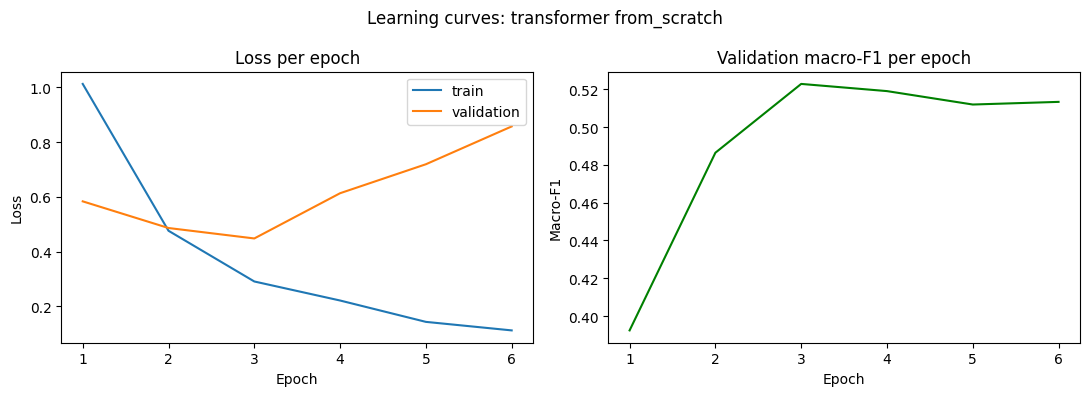

Backed up results to Google Drive


In [8]:
settings = BASE_SETTINGS.copy()

settings["from_scratch"] = True

settings["learning_rate"] = 5e-4

settings["epochs"] = 10

settings["patience"] = 3

settings["batch_size"] = 16

model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

evaluate_experiment(
    "from_scratch",
    settings,
    model,
    tokenizer,
    history,
    notes="Lower bound. Small random transformer with no pretraining.",
)

del model

transformer_training.clear_gpu_memory()

## 5. Experiments 2 to 4: three pretrained models

All three share the XLM-R architecture, so the main difference is **what they were pretrained on**:

| Model | Pretraining | Size |
|---|---|---|
| AfriBERTa large | About 1 GB of text in 11 African languages | 126M parameters |
| XLM-R base | 2.5 TB of text in 100 languages | 270M parameters |
| AfroXLMR base | XLM-R, further trained on 17 African languages | 270M parameters |

In our EDA, AfriBERTa's tokenizer used the fewest tokens per word (1.38 vs 1.56), so fewer articles are cut at 512 tokens. On the MasakhaNEWS Swahili benchmark, however, AfroXLMR (88.2) beat XLM-R (85.6), which beat AfriBERTa (83.3) (Adelani et al., 2023).

Random seed set to 42


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  503MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_large
Key                        | Status     | 
---------------------------+------------+-
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp

model.safetensors: reconstructing file:   0%|          |  0.00B /  503MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1: train loss 0.5599, validation loss 0.4737, validation macro-F1 0.5623
Epoch 2: train loss 0.3146, validation loss 0.3871, validation macro-F1 0.5784
Epoch 3: train loss 0.2091, validation loss 0.4587, validation macro-F1 0.6484
Epoch 4: train loss 0.1316, validation loss 0.4928, validation macro-F1 0.6819
Early stopping: no improvement for 2 epochs
              precision    recall  f1-score   support

     kitaifa       0.88      0.83      0.85       300
     michezo       0.95      0.99      0.97       258
    biashara       0.82      0.88      0.85       204
   kimataifa       1.00      0.12      0.22         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.89       772
   macro avg       0.73      0.56      0.58       772
weighted avg       0.89      0.89      0.88       772

Logged experiment 'afriberta' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


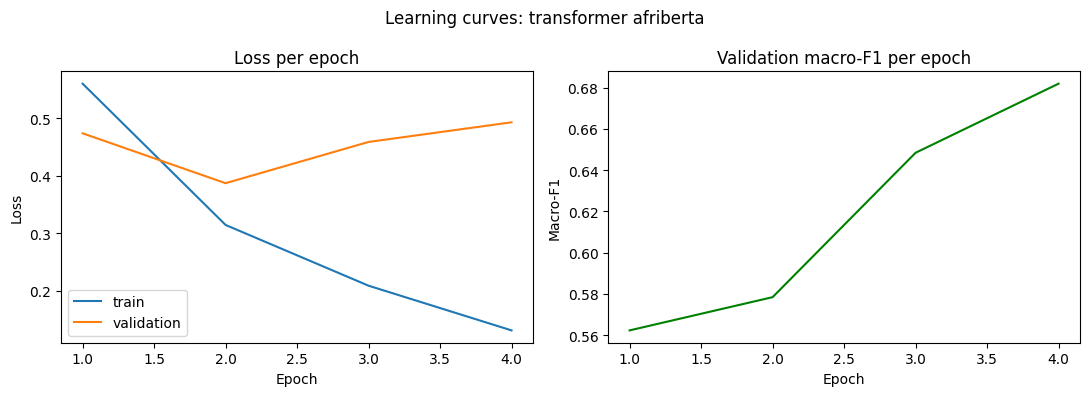

Backed up results to Google Drive


In [9]:
settings = BASE_SETTINGS.copy()

settings["checkpoint"] = "castorini/afriberta_large"

model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

evaluate_experiment(
    "afriberta",
    settings,
    model,
    tokenizer,
    history,
    notes="Small Africa-only pretraining. Most efficient tokenizer for Swahili in our EDA.",
)

del model

transformer_training.clear_gpu_memory()

Random seed set to 42


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda

Epoch 1: train loss 0.6799, validation loss 0.4985, validation macro-F1 0.5273
Epoch 2: train loss 0.3723, validation loss 0.4540, validation macro-F1 0.5347
Epoch 3: train loss 0.3002, validation loss 0.4440, validation macro-F1 0.5380
Epoch 4: train loss 0.2339, validation loss 0.4864, validation macro-F1 0.5412
              precision    recall  f1-score   support

     kitaifa       0.86      0.88      0.87       300
     michezo       0.94      0.98      0.96       258
    biashara       0.87      0.85      0.86       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.89       772
   macro avg       0.54      0.54      0.54       772
weighted avg       0.88      0.89      0.89       772

Logged experiment 'xlm_roberta' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


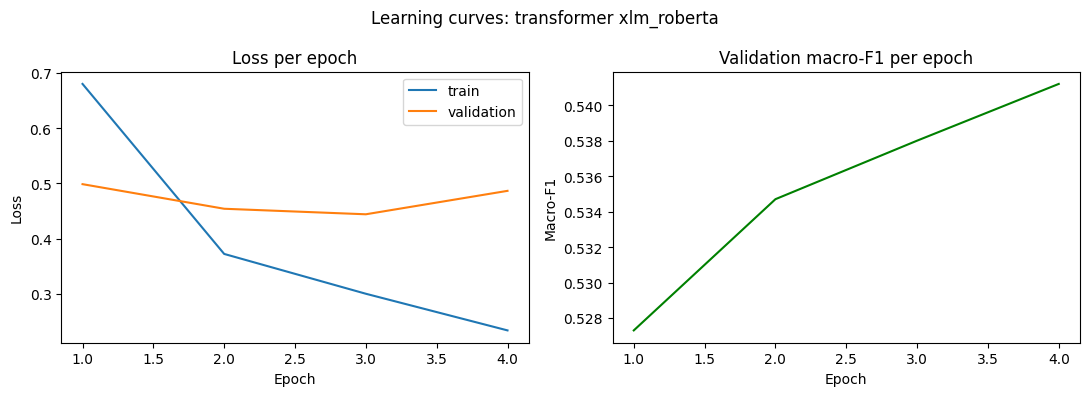

Backed up results to Google Drive


In [10]:
settings = BASE_SETTINGS.copy()

settings["checkpoint"] = "xlm-roberta-base"

model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

evaluate_experiment(
    "xlm_roberta",
    settings,
    model,
    tokenizer,
    history,
    notes="Large general multilingual pretraining (100 languages).",
)

del model

transformer_training.clear_gpu_memory()

Random seed set to 42


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` in

Epoch 1: train loss 0.6070, validation loss 0.3539, validation macro-F1 0.5411
Epoch 2: train loss 0.3021, validation loss 0.3560, validation macro-F1 0.5431
Epoch 3: train loss 0.2229, validation loss 0.3630, validation macro-F1 0.5905
Early stopping: no improvement for 2 epochs
              precision    recall  f1-score   support

     kitaifa       0.84      0.93      0.88       300
     michezo       0.95      0.98      0.97       258
    biashara       0.93      0.79      0.86       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.90       772
   macro avg       0.54      0.54      0.54       772
weighted avg       0.89      0.90      0.89       772

Logged experiment 'afro_xlmr' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


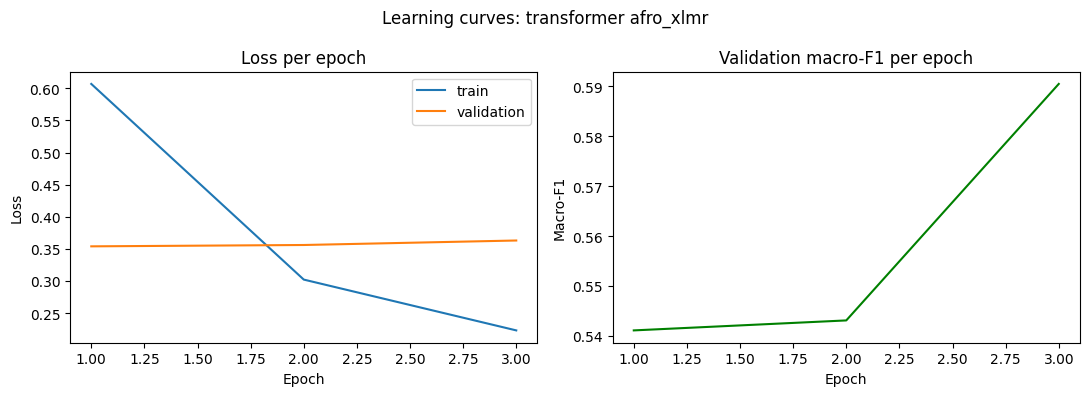

Backed up results to Google Drive


In [11]:
settings = BASE_SETTINGS.copy()

settings["checkpoint"] = "Davlan/afro-xlmr-base"

model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

evaluate_experiment(
    "afro_xlmr",
    settings,
    model,
    tokenizer,
    history,
    notes="XLM-R adapted to 17 African languages. Best on MasakhaNEWS Swahili.",
)

del model

transformer_training.clear_gpu_memory()

### Compare the pretrained models

The validation set has only 2 `burudani` and 8 `kimataifa` articles, so look at **macro-F1 and log loss together**, and at the per-class F1 columns, before choosing.

In [12]:
def show_experiment_log():
    transformer_log = pd.read_csv(EXPERIMENT_LOGS_DIRECTORY / f"{MODEL_NAME}.csv")

    columns_to_show = ["experiment", "split", "macro_f1", "log_loss", "accuracy", "f1_kimataifa", "f1_burudani"]

    return transformer_log[columns_to_show]


show_experiment_log()

,experiment,split,macro_f1,log_loss,accuracy,f1_kimataifa,f1_burudani
0,from_scratch,validation,0.5228,0.4481,0.8666,0.0000,0.0
1,afriberta,validation,0.5784,0.3871,0.8860,0.2222,0.0
2,xlm_roberta,validation,0.5380,0.4440,0.8925,0.0000,0.0
3,afro_xlmr,validation,0.5411,0.3539,0.8990,0.0000,0.0


**Decision: AfroXLMR.**

- It had the best validation accuracy (0.899) and the lowest log loss (0.354) of the three pretrained models.
- AfriBERTa had a higher macro-F1 (0.578 vs 0.541), but only because it classified one `kimataifa` article correctly. With 8 `kimataifa` and 2 `burudani` articles in validation, one article moves macro-F1 by several points, so we do not treat this as a real difference.
- The accuracy order (AfroXLMR > XLM-R > AfriBERTa) matches the MasakhaNEWS Swahili results (Adelani et al., 2023).

In [13]:
BEST_CHECKPOINT = "Davlan/afro-xlmr-base"

## 6. Experiment 5: keeping the start and the end of long articles

In our EDA, about a quarter to a third of articles are longer than 512 tokens, depending on the tokenizer. So far we kept only the first 510 tokens.

Sun et al. (2019) found that keeping the **first 128 and the last 382 tokens** worked best for long English and Chinese documents. The end of an article can hold useful clues, like quotes or the name of a team or a country.

Random seed set to 42


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2157 > 512). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` in

Epoch 1: train loss 0.6136, validation loss 0.3778, validation macro-F1 0.5394
Epoch 2: train loss 0.2959, validation loss 0.3424, validation macro-F1 0.5389
Epoch 3: train loss 0.2312, validation loss 0.3784, validation macro-F1 0.7199
Epoch 4: train loss 0.1647, validation loss 0.3936, validation macro-F1 0.7586
Early stopping: no improvement for 2 epochs
              precision    recall  f1-score   support

     kitaifa       0.89      0.85      0.87       300
     michezo       0.94      0.99      0.97       258
    biashara       0.84      0.88      0.86       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.89       772
   macro avg       0.53      0.54      0.54       772
weighted avg       0.88      0.89      0.89       772

Logged experiment 'best_model_head_tail' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


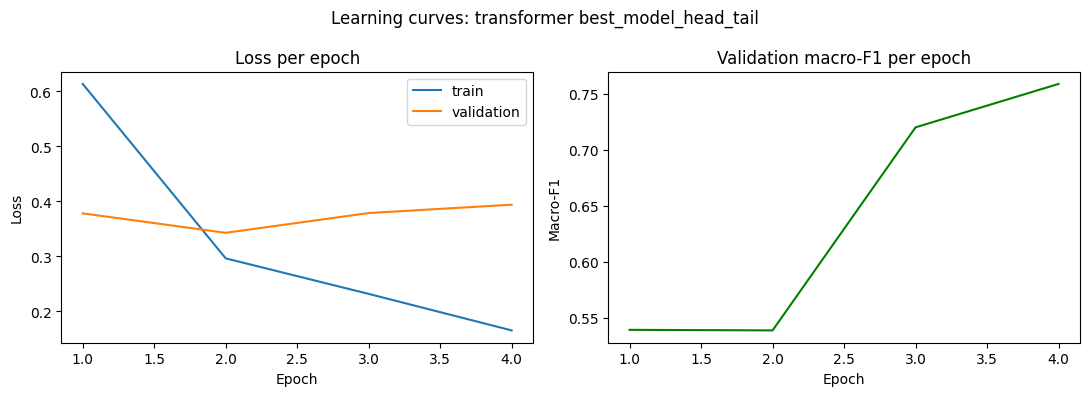

Backed up results to Google Drive


In [14]:
settings = BASE_SETTINGS.copy()

settings["checkpoint"] = BEST_CHECKPOINT

settings["strategy"] = "head_tail"

model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

evaluate_experiment(
    "best_model_head_tail",
    settings,
    model,
    tokenizer,
    history,
    notes="First 128 + last 382 tokens instead of the first 510 (Sun et al., 2019).",
)

del model

transformer_training.clear_gpu_memory()

In [15]:
show_experiment_log()

,experiment,split,macro_f1,log_loss,accuracy,f1_kimataifa,f1_burudani
0,from_scratch,validation,0.5228,0.4481,0.8666,0.0000,0.0
1,afriberta,validation,0.5784,0.3871,0.8860,0.2222,0.0
2,xlm_roberta,validation,0.5380,0.4440,0.8925,0.0000,0.0
3,afro_xlmr,validation,0.5411,0.3539,0.8990,0.0000,0.0
4,best_model_head_tail,validation,0.5389,0.3424,0.8938,0.0000,0.0


**Decision: keep `head` (the first 510 tokens).**

- Head plus tail scored almost the same as head only (macro-F1 0.539 vs 0.541, accuracy 0.894 vs 0.899).
- The topic of a news article is usually clear from its opening, so the extra tail tokens add little. Park et al. (2022) also found that simple truncation is usually as good as more complex methods for long documents.
- With no clear gain, we keep the simpler option.

In [16]:
BEST_STRATEGY = "head"

## 7. Experiment 6: class weights

With class weights, a mistake on a rare class costs more during training. The `balanced` weights are about 0.5 for `kitaifa` but about 65 for `burudani`, because `burudani` has only 11 training articles.

This could help the model notice rare classes, or it could make training unstable. Henning et al. (2023) review this and other methods for class imbalance in NLP.

Class weights: [ 0.51  0.6   0.76 18.96 65.51]
Random seed set to 42


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2157 > 512). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` in

Epoch 1: train loss 0.7738, validation loss 0.3599, validation macro-F1 0.5355
Epoch 2: train loss 0.4593, validation loss 0.3415, validation macro-F1 0.5824
Epoch 3: train loss 0.3134, validation loss 0.3375, validation macro-F1 0.7495
Epoch 4: train loss 0.2150, validation loss 0.3694, validation macro-F1 0.7747
              precision    recall  f1-score   support

     kitaifa       0.88      0.89      0.89       300
     michezo       0.95      0.98      0.97       258
    biashara       0.89      0.86      0.88       204
   kimataifa       0.80      0.50      0.62         8
    burudani       0.33      0.50      0.40         2

    accuracy                           0.91       772
   macro avg       0.77      0.75      0.75       772
weighted avg       0.91      0.91      0.91       772

Logged experiment 'best_model_class_weights' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


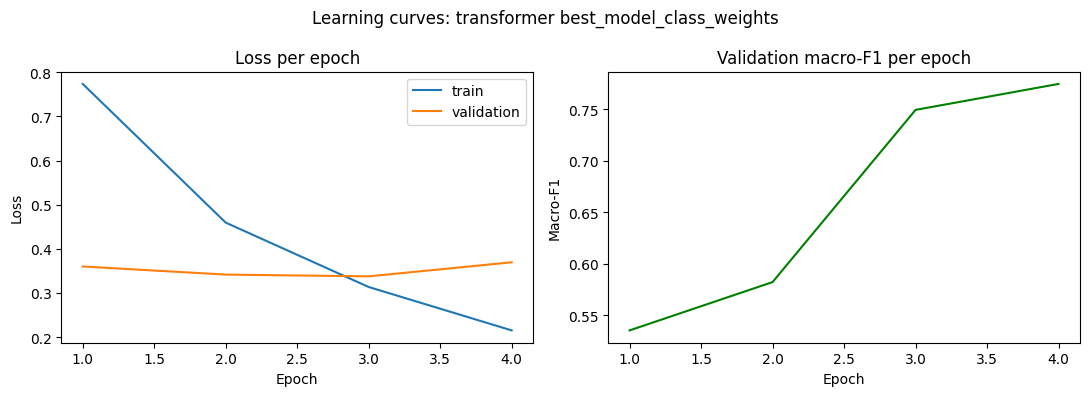

Backed up results to Google Drive


In [17]:
settings = BASE_SETTINGS.copy()

settings["checkpoint"] = BEST_CHECKPOINT

settings["strategy"] = BEST_STRATEGY

settings["class_weights"] = True

print("Class weights:", transformer_training.compute_class_weights(train).numpy().round(2))

model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

evaluate_experiment(
    "best_model_class_weights",
    settings,
    model,
    tokenizer,
    history,
    notes="Balanced class weights in the loss function.",
)

del model

transformer_training.clear_gpu_memory()

In [18]:
show_experiment_log()

,experiment,split,macro_f1,log_loss,accuracy,f1_kimataifa,f1_burudani
0,from_scratch,validation,0.5228,0.4481,0.8666,0.0000,0.0
1,afriberta,validation,0.5784,0.3871,0.8860,0.2222,0.0
2,xlm_roberta,validation,0.5380,0.4440,0.8925,0.0000,0.0
3,afro_xlmr,validation,0.5411,0.3539,0.8990,0.0000,0.0
4,best_model_head_tail,validation,0.5389,0.3424,0.8938,0.0000,0.0
5,best_model_class_weights,validation,0.7495,0.3375,0.9080,0.6154,0.4


**Decision: use class weights.**

- Class weights improved every validation metric: macro-F1 from 0.541 to 0.750, `kimataifa` F1 from 0.00 to 0.62, `burudani` F1 from 0.00 to 0.40, accuracy from 0.899 to 0.908, and log loss from 0.354 to 0.338.
- Without them, the model never predicted the two rare classes.
- This comes from one seed and a very small validation set, so the 3-seed final runs on the test set are what confirm it.

In [19]:
BEST_CLASS_WEIGHTS = True

## 8. Experiment 7: final model with 3 seeds and calibration

We train the final settings 3 times with different random seeds and report the mean and standard deviation. With so few rare-class articles, one run could be lucky or unlucky.

For each run, we also calibrate the probabilities with **temperature scaling** (Guo et al., 2017). The temperature is chosen on the validation set, then applied to the test set.

Temperature scaling does not change which class has the highest probability, so **accuracy and macro-F1 stay the same**. Only log loss changes.

This is the only section that uses the test set.

In [20]:
FINAL_SETTINGS = BASE_SETTINGS.copy()

FINAL_SETTINGS["checkpoint"] = BEST_CHECKPOINT

FINAL_SETTINGS["strategy"] = BEST_STRATEGY

FINAL_SETTINGS["class_weights"] = BEST_CLASS_WEIGHTS

FINAL_SETTINGS

{'epochs': 4,
 'patience': 2,
 'batch_size': 8,
 'strategy': 'head',
 'from_scratch': False,
 'learning_rate': 2e-05,
 'class_weights': False,
 'seed': 42,
 'checkpoint': 'Davlan/afro-xlmr-base'}

Random seed set to 42


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2157 > 512). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` in

Epoch 1: train loss 0.6072, validation loss 0.3676, validation macro-F1 0.5396
Epoch 2: train loss 0.3002, validation loss 0.3330, validation macro-F1 0.5415
Epoch 3: train loss 0.2262, validation loss 0.3605, validation macro-F1 0.7651
Epoch 4: train loss 0.1576, validation loss 0.3862, validation macro-F1 0.7239
Early stopping: no improvement for 2 epochs
Best temperature: 1.45 (validation log loss 0.2898)
Logged experiment 'final_seed_42_uncalibrated' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv
Logged experiment 'final_seed_42' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


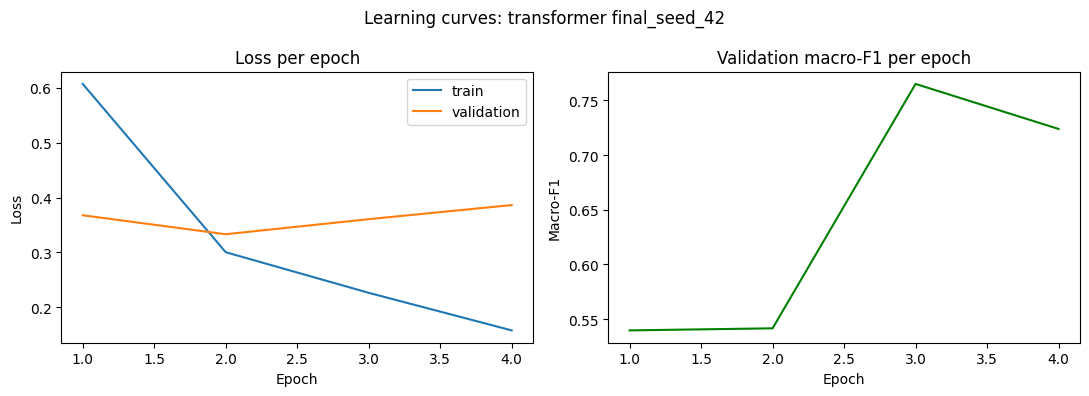

Backed up results to Google Drive
Random seed set to 7


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2157 > 512). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` in

Epoch 1: train loss 0.6064, validation loss 0.4384, validation macro-F1 0.5343
Epoch 2: train loss 0.2979, validation loss 0.4593, validation macro-F1 0.5209
Epoch 3: train loss 0.2172, validation loss 0.4392, validation macro-F1 0.6423
Early stopping: no improvement for 2 epochs
Best temperature: 1.45 (validation log loss 0.3784)
Logged experiment 'final_seed_7_uncalibrated' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv
Logged experiment 'final_seed_7' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


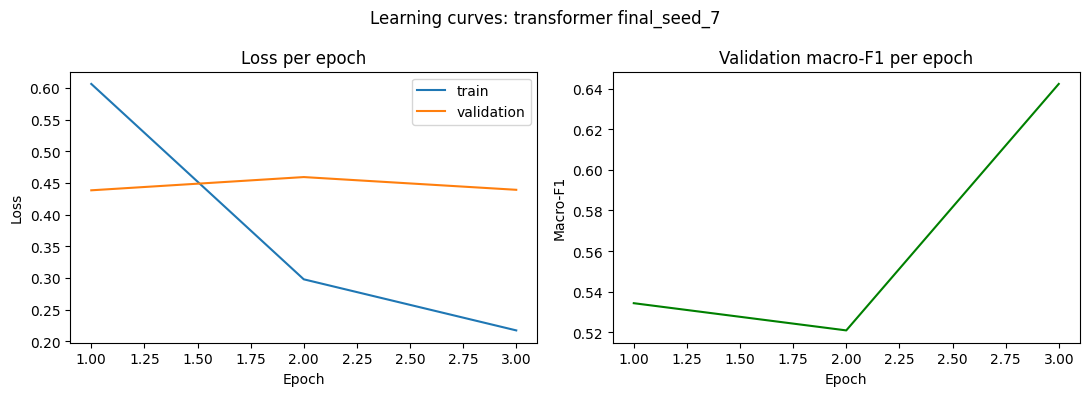

Backed up results to Google Drive
Random seed set to 2026


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2157 > 512). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/nlp_language_technologies/src/transformer_training.py:236: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` in

Epoch 1: train loss 0.6253, validation loss 0.3124, validation macro-F1 0.5391
Epoch 2: train loss 0.2991, validation loss 0.3106, validation macro-F1 0.5482
Epoch 3: train loss 0.2033, validation loss 0.3464, validation macro-F1 0.7230
Epoch 4: train loss 0.1454, validation loss 0.3806, validation macro-F1 0.7348
Early stopping: no improvement for 2 epochs
Best temperature: 1.45 (validation log loss 0.2740)
Logged experiment 'final_seed_2026_uncalibrated' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv
Logged experiment 'final_seed_2026' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


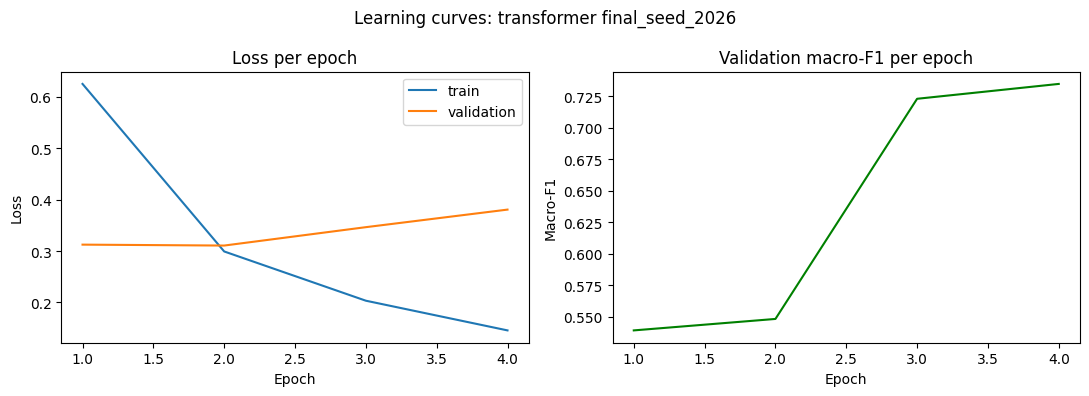

Backed up results to Google Drive


In [21]:
test_scores_per_seed = []

uncalibrated_test_scores_per_seed = []

for seed in FINAL_RUN_SEEDS:
    settings = FINAL_SETTINGS.copy()

    settings["seed"] = seed

    model, tokenizer, history = transformer_training.run_experiment(settings, train, validation)

    validation_logits = transformer_training.predict_article_logits(model, tokenizer, validation, settings)

    test_logits = transformer_training.predict_article_logits(model, tokenizer, test, settings)

    temperature = find_best_temperature(validation_logits, validation_ids)

    settings["temperature"] = temperature

    uncalibrated_test_scores = evaluation.compute_scores(test_ids, softmax(test_logits))

    test_scores = evaluation.compute_scores(test_ids, softmax(test_logits, temperature))

    log_experiment(
        MEMBER, MODEL_NAME, f"final_seed_{seed}_uncalibrated", "test", settings, uncalibrated_test_scores,
        "Final settings, before temperature scaling",
    )

    log_experiment(
        MEMBER, MODEL_NAME, f"final_seed_{seed}", "test", settings, test_scores,
        "Final settings, after temperature scaling",
    )

    plots.plot_learning_curves(history, MODEL_NAME, f"final_seed_{seed}")

    uncalibrated_test_scores_per_seed.append(uncalibrated_test_scores)

    test_scores_per_seed.append(test_scores)

    # We keep the first seed's model predictions for the figures and the Zindi submission
    if seed == FINAL_RUN_SEEDS[0]:
        final_test_probabilities = softmax(test_logits, temperature)

        zindi_logits = transformer_training.predict_article_logits(model, tokenizer, zindi_test, settings)

        final_zindi_probabilities = softmax(zindi_logits, temperature)

    del model

    transformer_training.clear_gpu_memory()

    back_up_results()

In [22]:
final_summary = evaluation.summarise_scores(test_scores_per_seed)

uncalibrated_summary = evaluation.summarise_scores(uncalibrated_test_scores_per_seed)

log_experiment(
    MEMBER, MODEL_NAME, "final_mean_of_seeds", "test", FINAL_SETTINGS, final_summary,
    "Mean and standard deviation of the 3 calibrated final runs",
)

summary_table = pd.DataFrame({
    "after calibration": final_summary,
    "before calibration": uncalibrated_summary,
})

summary_table.loc[["macro_f1", "macro_f1_std", "log_loss", "log_loss_std", "accuracy", "f1_kimataifa", "f1_burudani"]]

Logged experiment 'final_mean_of_seeds' to /content/nlp_language_technologies/results/experiment_logs/transformer.csv


,after calibration,before calibration
macro_f1,0.5639,0.5639
macro_f1_std,0.0509,0.0509
log_loss,0.3155,0.3584
log_loss_std,0.0482,0.0543
accuracy,0.8913,0.8913
f1_kimataifa,0.1333,0.1333
f1_burudani,0.0000,0.0000


## 9. Figures, errors and Zindi submission (first seed's model)

              precision    recall  f1-score   support

     kitaifa       0.91      0.81      0.86       300
     michezo       0.93      0.98      0.95       258
    biashara       0.81      0.94      0.87       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy                           0.89       773
   macro avg       0.53      0.55      0.54       773
weighted avg       0.88      0.89      0.88       773



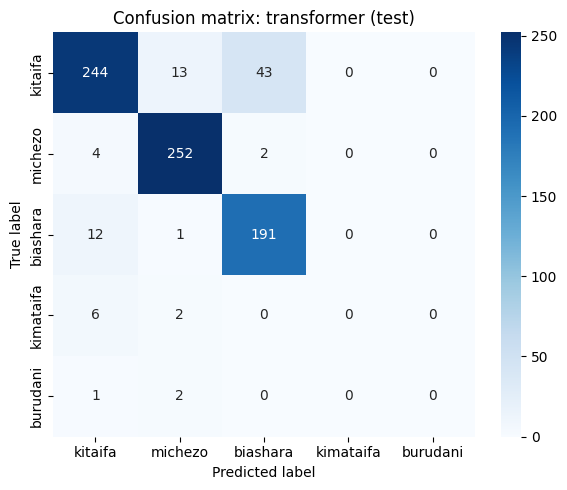

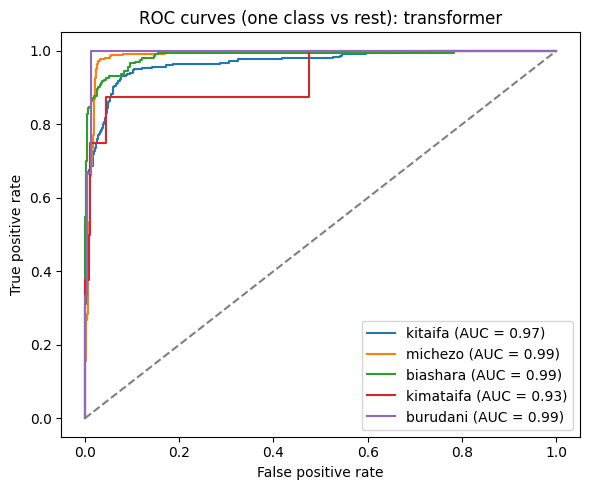

In [23]:
evaluation.print_classification_report(test_ids, final_test_probabilities)

plots.plot_confusion_matrix(test_ids, final_test_probabilities, MODEL_NAME, "test")

plots.plot_roc_curves(test_ids, final_test_probabilities, MODEL_NAME, "test")

In [24]:
evaluation.save_misclassified_examples(test, test_ids, final_test_probabilities, MODEL_NAME)

evaluation.save_zindi_submission(zindi_test, final_zindi_probabilities, MODEL_NAME)

back_up_results()

Saved 86 misclassified examples to /content/nlp_language_technologies/results/misclassified/transformer.csv
Saved Zindi submission to /content/nlp_language_technologies/results/submissions/transformer.csv
Backed up results to Google Drive


## 10. Download the results (Colab only)

Add the downloaded files to the repository under `results/`. They are also in your Google Drive backup folder.

In [25]:
if IN_COLAB:
    from google.colab import files

    !zip -r results.zip results
    files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/submissions/ (stored 0%)
  adding: results/submissions/transformer.csv (deflated 50%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/cnn/ (stored 0%)
  adding: results/figures/cnn/token_length_histogram.png (deflated 13%)
  adding: results/figures/cnn/roc_curves_test.png (deflated 12%)
  adding: results/figures/cnn/cnn (1).csv (deflated 12%)
  adding: results/figures/cnn/confusion_matrix_test_seed_7.png (deflated 10%)
  adding: results/figures/cnn/confusion_matrix_validation.png (deflated 6%)
  adding: results/figures/cnn/zipf_plot.png (deflated 10%)
  adding: results/figures/cnn/article_length_histogram.png (deflated 76%)
  adding: results/figures/cnn/cnn.csv (deflated 12%)
  adding: results/figures/cnn/learning_curves.png (deflated 11%)
  adding: results/figures/cnn/confusion_matrix_test_seed_42.png (deflated 13%)
  adding: results/figures/cnn/confusion_matrix_test_seed_2026.png (deflated 12%)
  adding: results/figure

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>